# Análise Exploratória — Fake News vs Notícias Verdadeiras

**Objetivo:** entender as principais características dos dados, identificar padrões, avaliar a qualidade dos dados e levantar desafios e oportunidades para as próximas etapas do projeto, como treinar um modelo de detecção de fake news.

**Base de Dados:** No nosso trabalho, utilizamos dois arquivos que constituem um dataset de fakenews com um arquivo csv para notícias verdadeiras e outro arquivo para notícias falsas. Esse dataset reúne checagens de notícias feitas por agências brasileiras e portuguesas (Lupa, Aos Fatos, Boatos.org, Polígrafo, AFP Checamos…).

| Arquivo | O que contém | `label` |
|---|---|---|
| `fakes.csv` | Alegações que as agências classificaram como **falsas** | 1 |
| `true.csv` | Alegações que as agências classificaram como **verdadeiras** | 0 |

**Roteiro do notebook**

1. Primeiro contato com os dados
2. Qualidade dos dados: o que está errado ou inconsistente?
3. Limpeza: como corrigimos, e por quê
4. Características gerais: tamanho, estilo, fontes e tempo
5. Padrões de conteúdo: sobre o que falam as fake news?
6. Temas mais comentados
7. Desafios e oportunidades para as próximas etapas

> Os arquivos originais **nunca são alterados**. Toda a limpeza acontece na memória.

In [1]:
import re
import unicodedata
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_colwidth", 120)
plt.rcParams.update({"figure.figsize": (11, 4.5), "axes.spines.top": False, "axes.spines.right": False})

# Cores fixas em todo o notebook: vermelho = fake, verde = verdadeira
COR = {"Fake": "#d62728", "Verdadeira": "#2ca02c"}

## 1. Primeiro contato com os dados

Os dois arquivos foram carregados e juntamos tudo em uma única tabela. A ideia era trabalhar com um único arquivo para conseguir fazer comparacões de maneira melhor.

In [2]:
fakes = pd.read_csv("datasets/fakes.csv")
true = pd.read_csv("datasets/true.csv")

bruto = pd.concat([fakes, true], ignore_index=True)
bruto["classe"] = bruto["label"].map({1: "Fake", 0: "Verdadeira"})

print(f"Fakes: {len(fakes):,} | Verdadeiras: {len(true):,} | Total: {len(bruto):,}")
bruto.sample(5, random_state=42)

Fakes: 20,478 | Verdadeiras: 2,720 | Total: 23,198


,title,text,origin,url,label,publisher_name,publisher_site,date,classe
11278,Governo comprou ventiladores à China por 20 mil euros cada mas em Portugal custam apenas 3.500 euros?,Governo comprou ventiladores à China por 20 mil euros cada mas em Portugal custam apenas 3.500 euros?,NaN,https://poligrafo.sapo.pt/fact-check/governo-comprou-ventiladores-a-china-por-20-mil-euros-cada-mas-em-portugal-cust...,1,Polígrafo - SAPO,poligrafo.sapo.pt,2020-03-26T09:00:25Z,Fake
3226,Mulher que faz denúncias em vídeo não é tia de Marielle Franco,"[Domingos Brazão] Ele foi eleito pelo DEM, pelo PT e pelo PSOL",Facebook,https://lupa.uol.com.br/jornalismo/2019/11/07/verificamos-video-tia-marielle-franco,1,Lupa - UOL,lupa.uol.com.br,2019-11-07T00:00:00Z,Fake
20412,Cientistas brasileiros descobriram que a proxalutamida cura a COVID-19?,Cientistas brasileiros descobriram que a proxalutamida cura a COVID-19,Grupos de WhatsApp,http://www.e-farsas.com/cientistas-brasileiros-descobriram-que-a-proxalutamida-cura-a-covid-19.html/,1,E-farsas,e-farsas.com,2021-03-17T00:00:00Z,Fake
7613,Vídeo de invasão a casa no Chile circula sem contexto como se fosse na Argentina,Mulher invade casa na Argentina após Alberto Fernández acabar com propriedade privada,Boatos de redes sociais,https://politica.estadao.com.br/blogs/estadao-verifica/argentina-fim-propriedade-casa-roubada/,1,Política - Estadão,politica.estadao.com.br,2022-07-15T19:32:50Z,Fake
247,É falso que diretor da OMS foi preso pela Interpol acusado de crime contra a humanidade,"“💥💥💥BREAKING NEWS 💥💥💥\n\nTedros Adhanom Ghebreyesus, o atual diretor da Organização Mundial da Saúde (OMS) foi preso...",Post no WhatsApp,https://lupa.uol.com.br/jornalismo/2022/07/29/diretor-oms-preso-interpol,1,Lupa - UOL,lupa.uol.com.br,2022-07-29T00:00:00Z,Fake


**O que cada coluna significa:**

- `title`: título do artigo de checagem, escrito pela agência
- `text`: a alegação que foi checada (o boato ou a frase do político)
- `origin`: de onde veio a alegação. Atenção: o significado muda entre os datasets (veja abaixo)
- `url`, `publisher_name`, `publisher_site`: o artigo e a agência que fez a checagem
- `date`: data da alegação ou da checagem

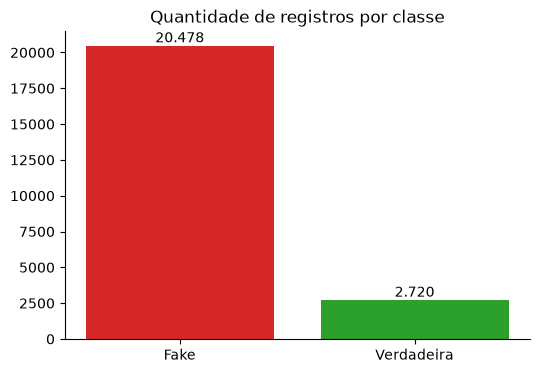

Proporção: 7.5 fakes para cada verdadeira


In [3]:
contagem = bruto["classe"].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(contagem.index, contagem.values, color=[COR[c] for c in contagem.index])
for i, v in enumerate(contagem.values):
    ax.text(i, v, f"{v:,}".replace(",", "."), ha="center", va="bottom")
ax.set_title("Quantidade de registros por classe")
plt.show()

print(f"Proporção: {contagem['Fake'] / contagem['Verdadeira']:.1f} fakes para cada verdadeira")

**Conclusão econtrada: as classes estão muito desbalanceadas, com cerca de 7,5 fakes para cada verdadeira.**

Isso traz duas consequências pra nossa aplicação envolvendo alguma tecnologia de IA:
- **Nesta análise**, comparamos as classes sempre por **porcentagem**, não fizemos por contagem absoluta. Fizermos isso porque as fakes "ganham" qualquer comparação só por serem mais numerosas.
- **No modelo**, um classificador que respondesse "fake" para tudo acertaria 88%. A acurácia sozinha não serve como métrica.

In [4]:
# O campo 'origin' tem significados diferentes em cada dataset
print("FAKES: valores mais comuns de origin")
print(fakes["origin"].value_counts().head(6), "\n")
print("VERDADEIRAS: valores mais comuns de origin")
print(true["origin"].value_counts().head(6))

FAKES: valores mais comuns de origin
origin
desinformação                2059
Mensagem em redes sociais    1724
Boatos de redes sociais      1187
Várias fontes                1148
Post no Facebook              946
Utilizador de Facebook        803
Name: count, dtype: int64 

VERDADEIRAS: valores mais comuns de origin
origin
Jair Bolsonaro      50
Geraldo Alckmin     29
Facebook            29
Post no Facebook    29
João Doria          27
Fernando Haddad     24
Name: count, dtype: int64


**Observação: o campo`origin` não significa a mesma coisa nos dois arquivos.**
- Nas **fakes**, indica **onde o boato circulou** (Facebook, WhatsApp, "redes sociais").
- Nas **verdadeiras**, indica **quem disse a frase**, quase sempre um político.

Por isso, `origin` **não deve ser comparado diretamente entre as classes**, nem usado como variável de um modelo: ele entregaria a resposta ("se é nome de político, é verdadeira").

---
## 2. Qualidade dos dados

Antes de tirar qualquer conclusão, fizemos a verificação de que se os dados são confiáveis. Procuramos cinco tipos de problema: **valores faltando, duplicados, inconsistências de escrita, textos problemáticos e datas estranhas**.

### 2.1 Valores faltando

In [5]:
nulos = bruto.groupby("classe")[["title", "text", "origin", "publisher_name", "date"]].apply(lambda g: g.isna().mean() * 100)
nulos.round(1)

,title,text,origin,publisher_name,date
classe,,,,,
Fake,0.0,0.0,22.7,1.8,14.8
Verdadeira,0.0,0.0,61.1,0.1,1.2


- `title` e `text` estão **sempre preenchidos**. Ótimo, porque são o conteúdo principal.
- `origin` falta em **23% das fakes e 61% das verdadeiras**.
- `date` falta em **15% das fakes**. Isso vai limitar as análises no tempo.

### 2.2 Duplicados

In [6]:
dup = bruto.duplicated(subset=["title", "text", "url"], keep=False)
print(f"Linhas envolvidas em duplicação: {dup.sum()}")
bruto[dup].sort_values("text")[["text", "url", "classe"]].head(6)

Linhas envolvidas em duplicação: 18


,text,url,classe
1969,Eu sempre (...) fiz justiça na forma da lei,https://lupa.uol.com.br/jornalismo/2021/11/11/moro-erra-lava-jato-desemprego,Fake
10234,Eu sempre (...) fiz justiça na forma da lei,https://lupa.uol.com.br/jornalismo/2021/11/11/moro-erra-lava-jato-desemprego,Fake
1649,"Hoje, 50% de todos os cargos de direção no partido são ocupados por mulheres",https://www.aosfatos.org/noticias/pt-diz-que-50-de-seus-cargos-sao-ocupados-por-mulheres-mas-numero-real-e-de-38/,Fake
18753,"Hoje, 50% de todos os cargos de direção no partido são ocupados por mulheres",https://www.aosfatos.org/noticias/pt-diz-que-50-de-seus-cargos-sao-ocupados-por-mulheres-mas-numero-real-e-de-38/,Fake
3673,Nunca vi o Lula pronunciar essa palavra [fascista] para se referir a ninguém,https://www.aosfatos.org/noticias/o-que-e-fato-e-o-que-nao-e-nas-declaracoes-de-haddad-na-ultima-semana-de-campanha/,Fake
19716,Nunca vi o Lula pronunciar essa palavra [fascista] para se referir a ninguém,https://www.aosfatos.org/noticias/o-que-e-fato-e-o-que-nao-e-nas-declaracoes-de-haddad-na-ultima-semana-de-campanha/,Fake


Existem poucos dados duplicados (a mesma alegação no mesmo artigo), provavelmente erros de coleta. **Vamos removê-los** para que não contem duas vezes.

### 2.3 Texto igual ao título

In [7]:
igual = bruto["text"].str.strip().str.lower() == bruto["title"].str.strip().str.lower()
print(f"Registros em que text == title: {igual.sum():,} ({igual.mean():.1%})")

Registros em que text == title: 4,083 (17.6%)


Em muitos registros, o `text` é só uma cópia do `title`. Não é exatamente um erro, mas se juntarmos título + texto para contar palavras, **essas palavras seriam contadas duas vezes**. 

### 2.4 Nomes de agência inconsistentes

In [8]:
agencias = bruto.groupby(["publisher_site", "publisher_name"], dropna=False).size()
agencias[agencias.index.get_level_values(0).isin(["noticias.uol.com.br", "politica.estadao.com.br", "piaui.folha.uol.com.br"])]

publisher_site           publisher_name                                           
noticias.uol.com.br      UOL Noticias                                                  474
                         UOL Notícias                                                  621
piaui.folha.uol.com.br   UOL                                                            72
politica.estadao.com.br  Política - Estadão                                           1337
                         Política | Notícias do governo, STF e Congresso - Estadão     530
                         NaN                                                           366
dtype: int64

**O mesmo site aparece com nomes diferentes**, como "UOL Noticias" e "UOL Notícias", ou os três nomes do Estadão, que às vezes vem sem nome. Num gráfico, isso aparece como agências diferentes. **Solução:** usar o **site** (`publisher_site`), que é sempre consistente, para definir um nome único.

### 2.5 Variações em `origin`

In [9]:
origem = bruto["origin"].dropna().str.strip()
variantes = origem.groupby(origem.str.lower()).agg(lambda s: sorted(s.unique())).loc[lambda s: s.str.len() > 1]
print(f"Valores distintos: {origem.nunique()} | ignorando maiúsculas: {origem.str.lower().nunique()}")
print("\nExemplos de variações de maiúsculas/minúsculas:")
print(variantes.head(5).to_string())
print("\nSinônimos (mesma coisa, escrita diferente):")
print(origem[origem.str.lower().str.contains("utilizador d|post (?:no|do) facebook")].value_counts())

Valores distintos: 1503 | ignorando maiúsculas: 1479

Exemplos de variações de maiúsculas/minúsculas:
origin
"boato de internet"        ["Boato de Internet", "Boato de internet", "boato de internet"]
boato de internet                [Boato de Internet, Boato de internet, boato de internet]
boato de redes sociais                    [Boato de Redes Sociais, Boato de redes sociais]
boato de whatsapp                                   [Boato de WhatsApp, Boato de Whatsapp]
boatos de redes sociais                 [Boatos de redes sociais, boatos de redes sociais]

Sinônimos (mesma coisa, escrita diferente):
origin
Post no Facebook                                                                                             975
Utilizador de Facebook                                                                                       803
Utilizador do Facebook                                                                                       595
Post do Facebook                             

Encontramos a mesma origem escrita de formas diferentes: maiúsculas, "de" / "do" e "no" / "do". Também há valores que **não indicam origem nenhuma**, como "desinformação" e "checamos", que são rótulos genéricos das agências.

### 2.6 Datas

In [10]:
datas = pd.to_datetime(bruto["date"], errors="coerce", utc=True, format="ISO8601").dt.tz_convert(None)
partes = bruto["url"].str.extract(r"/(20\d\d)/(\d\d)/(\d\d)/")
data_na_url = pd.to_datetime(partes[0] + "-" + partes[1] + "-" + partes[2], errors="coerce")

print(f"Período: {datas.min():%d/%m/%Y} a {datas.max():%d/%m/%Y}")
print(f"Datas antes de 2010: {(datas < '2010').sum()}")
print(bruto.loc[datas < "2010", ["date", "publisher_name"]].to_string(), "\n")
print(f"Datas vazias que podem ser recuperadas pela URL: {(datas.isna() & data_na_url.notna()).sum()}")

Período: 10/09/2005 a 21/12/2022
Datas antes de 2010: 1
                       date publisher_name
17256  2005-09-10T08:34:21Z     Observador 

Datas vazias que podem ser recuperadas pela URL: 502


- Há uma data de **2005 no Observador, que só foi fundado em 2014**. É um erro claro, então anulamos essa data.
- Muitas URLs trazem a data no endereço (`/2022/09/08/`). Isso permite **recuperar cerca de 500 datas vazias**.

### Resumo da qualidade

| Problema | Gravidade | O que faremos |
|---|---|---|
| Classes desbalanceadas | Alta | Usar porcentagens; tratar na modelagem |
| `origin` com significados diferentes | Alta | Não usar como variável do modelo |
| `date` vazia (15% das fakes) | Média | Recuperar pela URL quando possível |
| Nomes de agência inconsistentes | Média | Padronizar pelo site |
| Variações em `origin` | Baixa | Unificar grafias |
| `text` == `title` | Baixa | Não contar palavras em dobro |
| Duplicados, data impossível, espaços e aspas | Baixa | Remover ou corrigir |

---
## 3. Limpeza

Aplicamos as correções acima. Prefirimos seguir a regra de corrigir quando há certeza e marcar (não apagar) quando há dúvida. Isso porque se um registro estiver sem data, por exemplo, ainda serviria para analisar o texto, então não o descartamos logo de cara.

In [11]:
# Nome oficial de cada agência, definido pelo site
AGENCIAS = {
    "aosfatos.org": "Aos Fatos", "boatos.org": "Boatos.org", "bol.uol.com.br": "BOL - UOL",
    "checamos.afp.com": "AFP Checamos", "e-farsas.com": "E-farsas", "lupa.uol.com.br": "Lupa - UOL",
    "noticias.uol.com.br": "UOL Notícias", "observador.pt": "Observador",
    "piaui.folha.uol.com.br": "Revista Piauí", "poligrafo.sapo.pt": "Polígrafo - SAPO",
    "politica.estadao.com.br": "Estadão", "projetocomprova.com.br": "Projeto Comprova",
}

# Escritas diferentes da mesma origem (chave em minúsculas)
SINONIMOS_ORIGEM = {
    "utilizador de facebook": "Utilizador do Facebook", "utilizador do facebook": "Utilizador do Facebook",
    "post do facebook": "Post no Facebook", "post no facebook": "Post no Facebook",
    "publicação no facebook": "Post no Facebook", "boato de redes sociais": "Boatos de redes sociais",
    "boatos de redes sociais": "Boatos de redes sociais", "boatos nas redes sociais": "Boatos de redes sociais",
    "múltiplas fontes": "Várias fontes", "várias fontes": "Várias fontes",
    "mensagem no whatsapp": "Mensagem no WhatsApp", "post no whatsapp": "Mensagem no WhatsApp",
    "lula": "Luiz Inácio Lula da Silva",
}
ORIGENS_GENERICAS = {"desinformação", "checamos"}


def limpar_texto(serie):
    """Remove espaços invisíveis, quebras de linha e aspas nas bordas."""
    serie = serie.str.replace(r"[ ​‌‍﻿]", " ", regex=True)
    serie = serie.str.replace(r"\s+", " ", regex=True).str.strip()
    return serie.str.strip("\"'“”‘’«»").str.strip()


df = bruto.copy()
for col in ["title", "text", "origin"]:
    df[col] = limpar_texto(df[col])

# 1. Duplicados
df = df.drop_duplicates(subset=["title", "text", "url"])

# 2. Texto igual ao título
df["text_igual_title"] = df["text"].str.lower() == df["title"].str.lower()

# 3. Agência padronizada
df["agencia"] = df["publisher_site"].map(AGENCIAS).fillna(df["publisher_name"])

# 4. Origem: sinônimos, depois a grafia mais comum para variações de maiúsculas
chave = df["origin"].str.lower()
grafia_comum = df["origin"].groupby(chave).agg(lambda s: s.value_counts().index[0])
df["origin"] = chave.map(SINONIMOS_ORIGEM).fillna(chave.map(grafia_comum)).mask(chave.isin(ORIGENS_GENERICAS))

# 5. Datas: anula as impossíveis e recupera as vazias pela URL
partes = df["url"].str.extract(r"/(20\d\d)/(\d\d)/(\d\d)/")
data_url = pd.to_datetime(partes[0] + "-" + partes[1] + "-" + partes[2], errors="coerce")
df["date"] = pd.to_datetime(df["date"], errors="coerce", utc=True, format="ISO8601").dt.tz_convert(None)
df["date"] = df["date"].mask(df["date"] < "2010-01-01").fillna(data_url)

# Colunas auxiliares para as análises
df["texto_completo"] = df["title"].where(df["text_igual_title"], df["title"] + " " + df["text"])
df["n_palavras"] = df["text"].str.split().str.len()

In [12]:
print(f"Linhas: {len(bruto):,} -> {len(df):,}  (duplicados removidos: {len(bruto) - len(df)})")
print(f"Nomes de agência: {bruto['publisher_name'].nunique()} -> {df['agencia'].nunique()}")
print(f"Valores de origin: {bruto['origin'].nunique()} -> {df['origin'].nunique()}")
print(f"Datas vazias: {bruto['date'].isna().sum():,} -> {df['date'].isna().sum():,}")

Linhas: 23,198 -> 23,189  (duplicados removidos: 9)
Nomes de agência: 14 -> 12
Valores de origin: 1503 -> 1462
Datas vazias: 3,070 -> 2,569


Os dados agora estão consistentes. O que **não tem como corrigir**, como as fakes do Boatos.org sem data em lugar nenhum, fica de fora só das análises por data.

> O script `00_limpeza.py` aplica essa mesma limpeza e também exporta os dados limpos para `datasets/limpos/`, com um arquivo `nao_tratados.csv` listando os casos não resolvidos.

---
## 4. Características gerais

### 4.1 Tamanho dos textos
**Pergunta:** fake news são mais longas ou mais curtas?

              count  mean   std  min   25%   50%   75%     max
classe                                                        
Fake        20469.0  18.7  19.2  1.0  11.0  14.0  21.0  1171.0
Verdadeira   2720.0  15.2   6.9  4.0  12.0  14.0  17.0   107.0


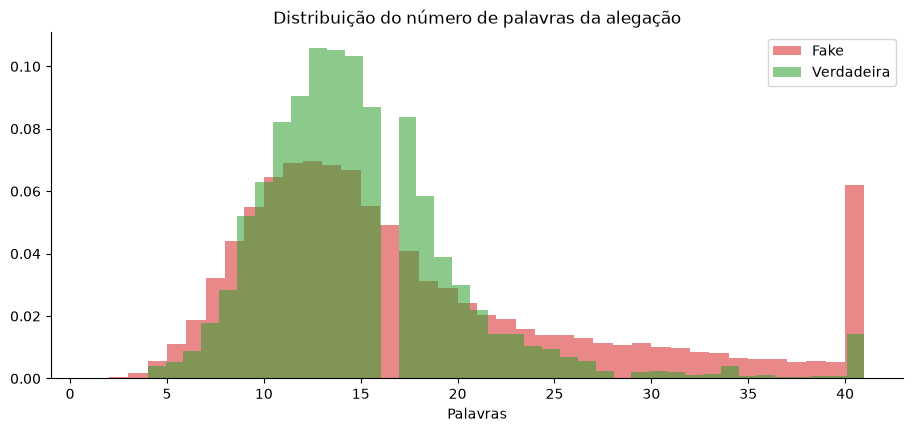

In [13]:
print(df.groupby("classe")["n_palavras"].describe().round(1))

limite = df["n_palavras"].quantile(0.95)  # corta os 5% maiores para o gráfico ficar legível
fig, ax = plt.subplots()
for classe, grupo in df.groupby("classe"):
    ax.hist(grupo["n_palavras"].clip(upper=limite), bins=40, density=True, alpha=0.55, color=COR[classe], label=classe)
ax.set_title("Distribuição do número de palavras da alegação")
ax.set_xlabel("Palavras")
ax.legend()
plt.show()

A **mediana é igual (14 palavras)**, mas as fakes variam muito mais: vão de 1 a mais de 1.000 palavras. As verdadeiras são frases curtas e regulares, porque quase sempre são **declarações de políticos**. As fakes incluem desde frases soltas até correntes inteiras de WhatsApp.

### 4.2 Estilo de escrita
**Pergunta:** fakes são mais "alarmistas" ou apelativas? Medimos o uso de LETRAS MAIÚSCULAS e de pontos de exclamação.

In [14]:
def pct_maiusculas(texto):
    letras = [c for c in texto if c.isalpha()]
    return 100 * sum(c.isupper() for c in letras) / max(len(letras), 1)

df["pct_maiusculas"] = df["text"].apply(pct_maiusculas)
df["exclamacoes"] = df["text"].str.count("!")
df["tem_exclamacao"] = df["exclamacoes"] > 0

df.groupby("classe")[["pct_maiusculas", "exclamacoes", "tem_exclamacao"]].mean().round(3)

,pct_maiusculas,exclamacoes,tem_exclamacao
classe,,,
Fake,8.154,0.156,0.079
Verdadeira,6.120,0.011,0.008


**Conclusão: as fakes têm mais maiúsculas e muito mais exclamações.** O tom alarmista ("COMPARTILHEM!!!") é típico de boatos. Essas medidas são **boas candidatas a variáveis do modelo**, porque não dependem do assunto.

### 4.3 Quem fez as checagens

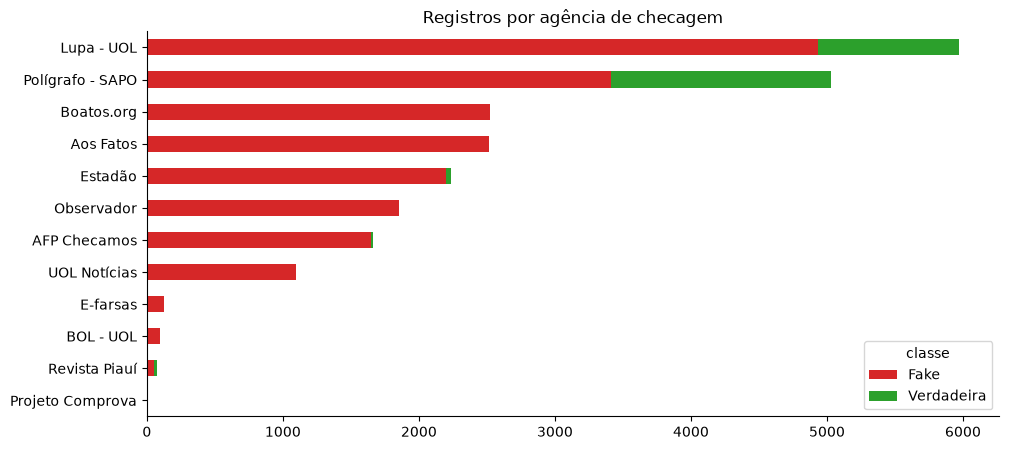

Origem das verdadeiras (%):
agencia
Polígrafo - SAPO    59.3
Lupa - UOL          38.0
Estadão              1.2
Name: Verdadeira, dtype: float64


In [15]:
por_agencia = df.groupby(["agencia", "classe"]).size().unstack(fill_value=0)
por_agencia = por_agencia.loc[por_agencia.sum(axis=1).sort_values().index]

fig, ax = plt.subplots(figsize=(11, 5))
por_agencia.plot.barh(ax=ax, stacked=True, color=[COR["Fake"], COR["Verdadeira"]])
ax.set_title("Registros por agência de checagem")
ax.set_ylabel("")
plt.show()

pct_true = (por_agencia["Verdadeira"] / por_agencia["Verdadeira"].sum() * 100).sort_values(ascending=False)
print("Origem das verdadeiras (%):")
print(pct_true.head(3).round(1))

 **Este é um dos pontos mais importantes da análise.**

- **Cerca de 97% das verdadeiras vêm de só duas agências:** o Polígrafo (Portugal) e a Lupa.
- Várias agências, como Aos Fatos, Boatos.org e Observador, **só aparecem nas fakes**.

Isso cria um **viés de fonte**: um modelo pode aprender "português de Portugal = verdadeira", em vez de aprender o que torna uma notícia falsa.

### 4.4 Distribuição no tempo

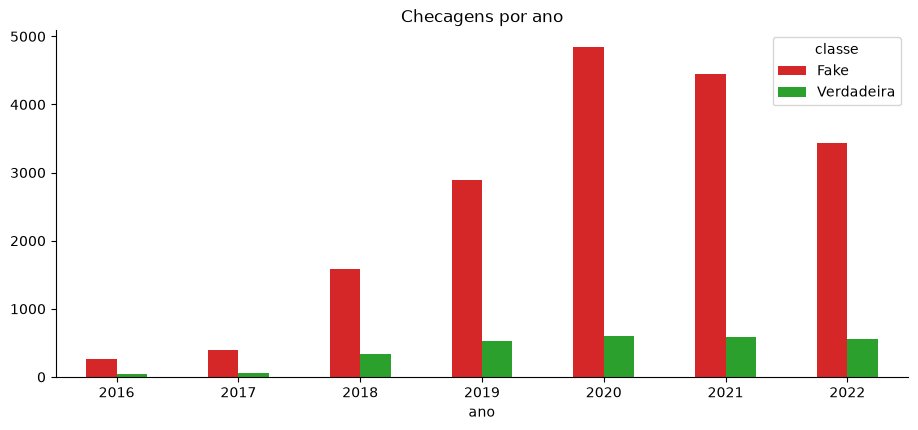

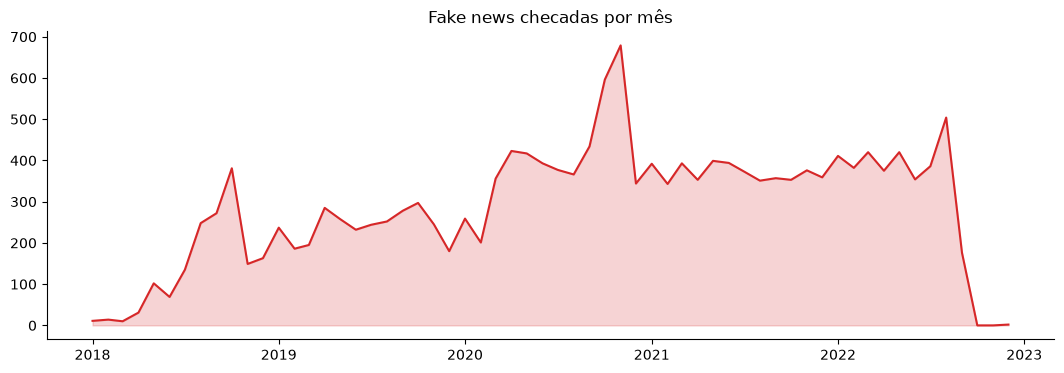

Meses com mais fake news:
date
2020-11-01    679
2020-10-01    596
2022-08-01    504
2020-09-01    434
dtype: int64


In [16]:
por_ano = df.dropna(subset=["date"]).assign(ano=lambda d: d["date"].dt.year).query("ano >= 2016")
por_ano = por_ano.groupby(["ano", "classe"]).size().unstack(fill_value=0)

fig, ax = plt.subplots()
por_ano.plot.bar(ax=ax, color=[COR["Fake"], COR["Verdadeira"]])
ax.set_title("Checagens por ano")
ax.tick_params(axis="x", rotation=0)
plt.show()

fakes_mes = df.query("classe == 'Fake'").dropna(subset=["date"]).set_index("date").resample("MS").size()
fakes_mes = fakes_mes["2018":]
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(fakes_mes.index, fakes_mes.values, color=COR["Fake"])
ax.fill_between(fakes_mes.index, fakes_mes.values, alpha=0.2, color=COR["Fake"])
ax.set_title("Fake news checadas por mês")
plt.show()

print("Meses com mais fake news:")
print(fakes_mes.nlargest(4))

 **Os picos de fake news coincidem com eventos:** eleições municipais (out/nov de 2020), início da pandemia (2020) e campanha presidencial (ago/2022).

- As **verdadeiras se concentram em anos eleitorais**, porque são checagens de discursos e debates.
- Os dados **terminam em 2022**. Assuntos novos, surgidos depois disso, não estão representados, e um modelo treinado aqui pode envelhecer rápido.

---
## 5. Padrões de conteúdo: sobre o que falam as fake news?

Para contar palavras, primeiro removemos as **stopwords**, palavras muito frequentes que não carregam assunto ("de", "que", "para"…). Também removemos **termos das próprias agências**, como "boato", "fact check" e "erros e acertos". Eles aparecem em muitos títulos, mas descrevem a checagem, não o assunto.

In [17]:
STOPWORDS = set("""
a à ao aos as às até após com como contra da das de dela dele deles do dos e é em entre era eram essa esse
esta está estão este eu foi foram há isso isto já la lá lhe mais mas me mesmo meu minha muito na nas nem no
nos nós não o os ou para pela pelas pelo pelos por qual quando que quem se sem seu seus sua suas são só também
te tem têm ter um uma umas uns vai vão você ser sobre seja ainda aqui ali assim cada depois desde disse diz
dizem ela ele eles elas esses essas estes estas estava estavam faz fazer sido sim tão todo toda todos todas
tudo vez vezes vídeo video foto imagem post publicação publicações mostra mostram falso falsa verdadeiro
verdadeira enganoso enganosa teria teriam através onde porque pois seria será serão sendo tinha tinham outro
outra outros outras apenas agora ano anos dia dias pode
fact check checagem boato boatos erra erro erros acerta acertos engana confirma verdade mentira falar afirma
""".split())


def tokenizar(texto):
    texto = re.sub(r"https?://\S+", " ", texto.lower())
    return [p for p in re.findall(r"[a-zà-ÿ]+", texto) if len(p) >= 3 and p not in STOPWORDS]


def top_palavras(textos, n=20):
    contador = Counter()
    for t in textos:
        contador.update(tokenizar(t))
    return pd.Series(dict(contador.most_common(n)))


def top_bigramas(textos, n=20):
    contador = Counter()
    for t in textos:
        tokens = tokenizar(t)
        contador.update(" ".join(par) for par in zip(tokens, tokens[1:]))
    return pd.Series(dict(contador.most_common(n)))

### 5.1 Palavras mais frequentes em cada classe

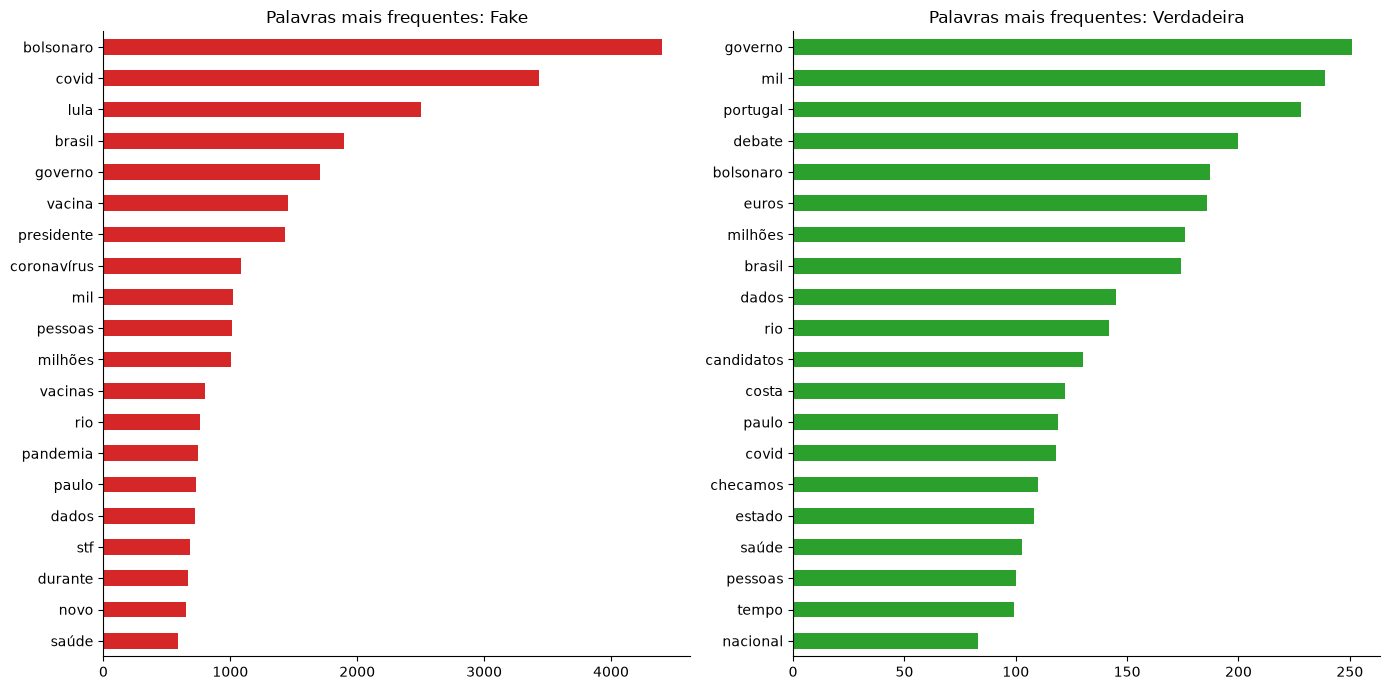

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for ax, classe in zip(axes, ["Fake", "Verdadeira"]):
    top_palavras(df.loc[df["classe"] == classe, "texto_completo"]).sort_values().plot.barh(ax=ax, color=COR[classe])
    ax.set_title(f"Palavras mais frequentes: {classe}")
plt.tight_layout()
plt.show()

- **Fakes:** o vocabulário é dominado por **Bolsonaro, Covid, Lula, vacina e governo**, ou seja, política e pandemia.
- **Verdadeiras:** aparecem **Portugal, euros e debate**, reflexo do peso do Polígrafo e das checagens de debates eleitorais.

### 5.2 Pares de palavras nas fakes
Os bigramas (duas palavras seguidas) dão mais contexto do que palavras soltas.

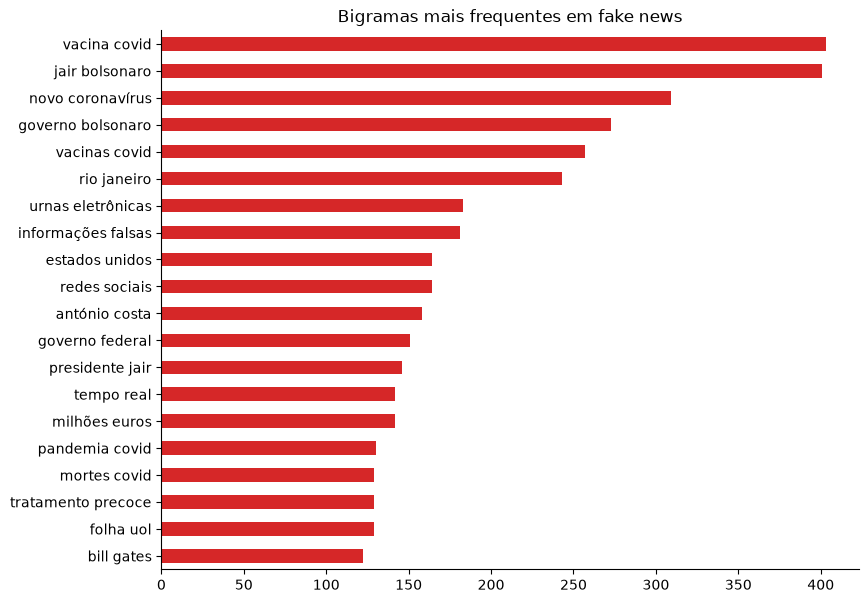

In [19]:
fig, ax = plt.subplots(figsize=(9, 7))
top_bigramas(df.loc[df["classe"] == "Fake", "texto_completo"]).sort_values().plot.barh(ax=ax, color=COR["Fake"])
ax.set_title("Bigramas mais frequentes em fake news")
plt.show()

Os bigramas confirmam os grandes assuntos: **vacina/Covid, Jair Bolsonaro, urnas eletrônicas, tratamento precoce, Bill Gates**. Vários deles são **narrativas conhecidas de desinformação**, como fraude nas urnas, tratamento precoce e teorias sobre Bill Gates.

### 5.3 Vocabulário característico de cada classe
Percebemos que frequência sozinha engana: "Brasil" aparece muito nas duas classes. Queremos saber quais palavras são **típicas** de uma classe em comparação com a outra. Para isso usamos o **log-odds**:

> log-odds = log(frequência da palavra nas fakes) − log(frequência nas verdadeiras)

Valores altos indicam palavras muito mais comuns nas fakes, e valores baixos, nas verdadeiras. Somamos 1 às contagens (suavização) para não dividir por zero, e só consideramos palavras com pelo menos 20 ocorrências, para evitar palavras raras.

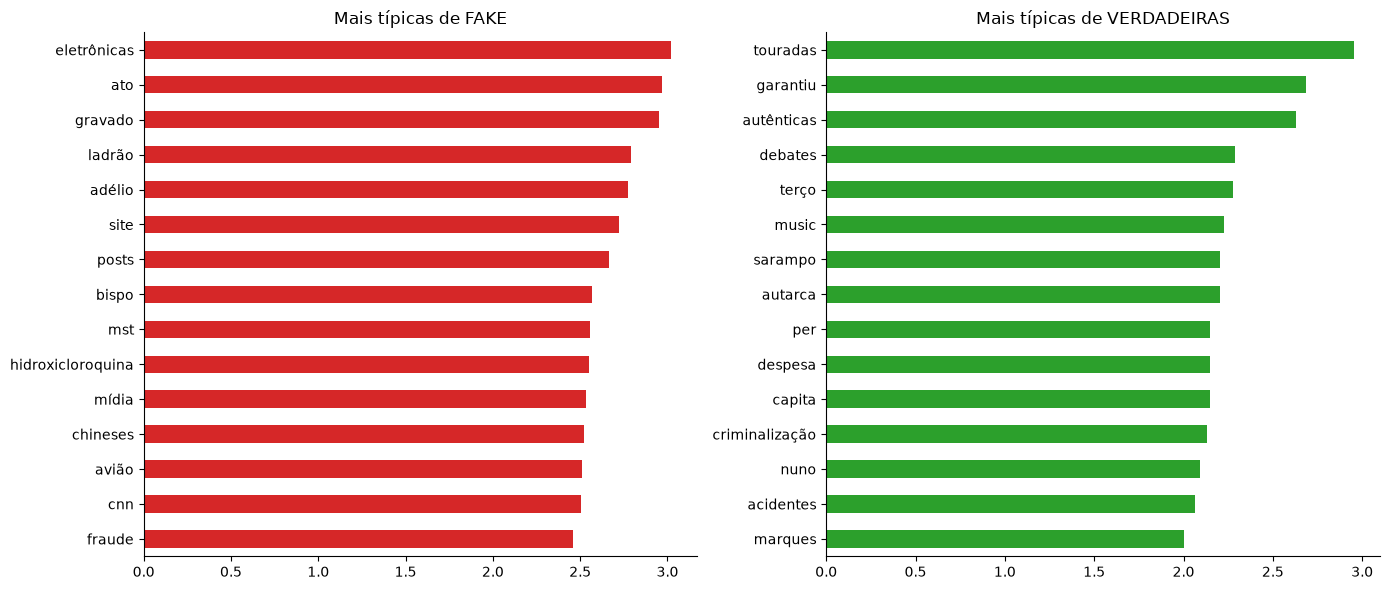

In [20]:
cont = {c: Counter(p for t in df.loc[df["classe"] == c, "texto_completo"] for p in tokenizar(t)) for c in COR}
vocab = [p for p in set(cont["Fake"]) | set(cont["Verdadeira"]) if cont["Fake"][p] + cont["Verdadeira"][p] >= 20]
total = {c: sum(cont[c].values()) + len(vocab) for c in COR}

log_odds = pd.Series({p: np.log((cont["Fake"][p] + 1) / total["Fake"]) - np.log((cont["Verdadeira"][p] + 1) / total["Verdadeira"])
                      for p in vocab})

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
log_odds.nlargest(15).sort_values().plot.barh(ax=axes[0], color=COR["Fake"])
axes[0].set_title("Mais típicas de FAKE")
log_odds.nsmallest(15).abs().sort_values().plot.barh(ax=axes[1], color=COR["Verdadeira"])
axes[1].set_title("Mais típicas de VERDADEIRAS")
plt.tight_layout()
plt.show()

📌 **Achado: as palavras típicas de fake revelam as narrativas de desinformação.** Aparecem **"eletrônicas"** (urnas), **"ladrão"**, **"Adélio"** (o autor da facada), **"hidroxicloroquina"**, **"MST"**, **"mídia"** e **"fraude"**.

⚠️ As palavras típicas de verdadeiras são quase todas **portuguesas**: Setúbal, autarquia, CDU, défice e touradas. Isso **confirma o viés de fonte** visto na seção 4.3.

### 5.4 Onde as fake news circulam
Usamos o campo `origin` (só nas fakes) para identificar a rede social.

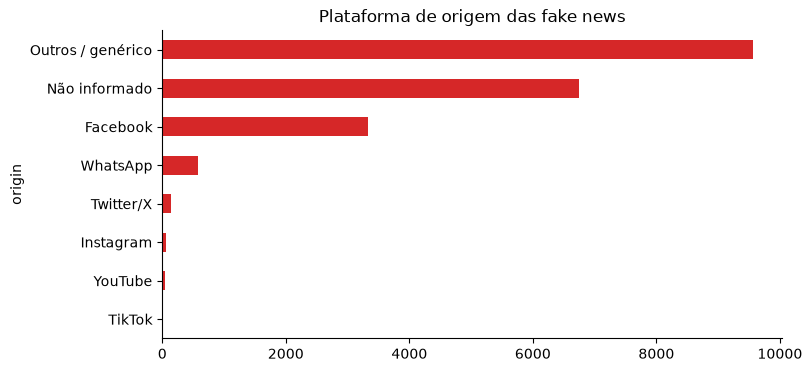

In [21]:
PLATAFORMAS = {"WhatsApp": r"whats|zap", "Facebook": r"facebook", "Twitter/X": r"twitter|tweet",
               "Instagram": r"instagram", "YouTube": r"youtube", "TikTok": r"tiktok|tik tok"}


def plataforma(origem):
    if pd.isna(origem):
        return "Não informado"
    for nome, padrao in PLATAFORMAS.items():
        if re.search(padrao, origem.lower()):
            return nome
    return "Outros / genérico"


plataformas = df.loc[df["classe"] == "Fake", "origin"].apply(plataforma).value_counts()
fig, ax = plt.subplots(figsize=(8, 4))
plataformas.sort_values().plot.barh(ax=ax, color=COR["Fake"])
ax.set_title("Plataforma de origem das fake news")
plt.show()

Entre os casos em que a plataforma foi identificada, o **Facebook predomina**, seguido do **WhatsApp**. Mas a maior parte está como "genérico" ("redes sociais", "várias fontes") ou vazia. **O campo `origin` é pouco informativo** para responder essa pergunta com precisão.

---
## 6. Temas mais comentados

Para agrupar os registros por assunto, criamos um **dicionário de temas com palavras-chave**. Os temas foram escolhidos a partir das palavras e bigramas da seção 5 e do contexto da época (eleições, pandemia, guerra). A busca é feita em texto **sem acento**, e um mesmo registro pode ter **mais de um tema**.

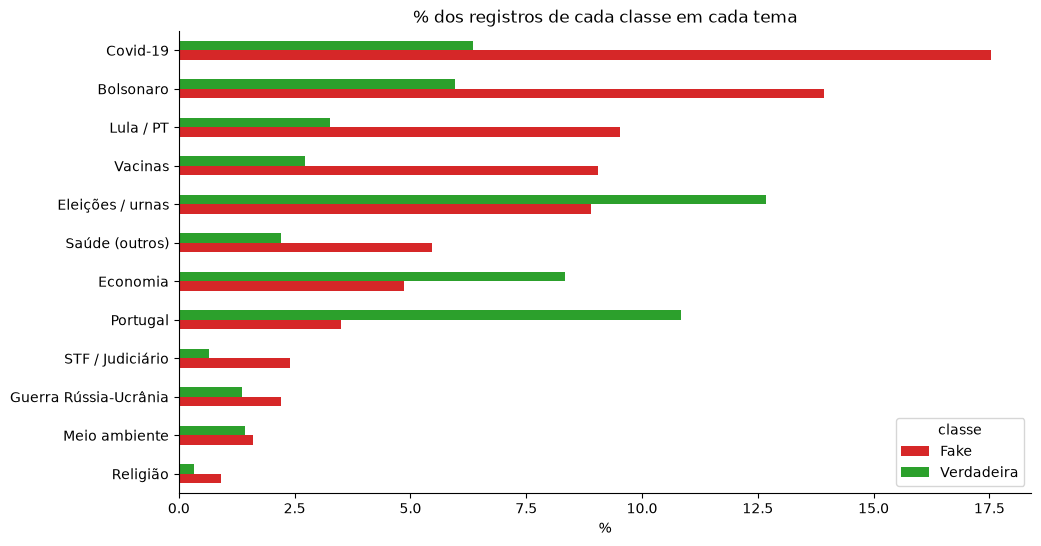

Registros sem nenhum tema: 42%


In [22]:
TEMAS = {
    "Eleições / urnas": r"eleic|urna|tse|voto|votac|eleitor|candidat",
    "Bolsonaro": r"bolsonaro",
    "Lula / PT": r"\blula\b|\bpt\b|petista",
    "STF / Judiciário": r"\bstf\b|supremo|moraes",
    "Covid-19": r"covid|coronavirus|pandemia|quarentena|lockdown",
    "Vacinas": r"vacin|imuniz|pfizer|coronavac|astrazeneca",
    "Saúde (outros)": r"cancer|doenca|remedio|medicament|hospital|ivermectina|cloroquina",
    "Economia": r"economi|inflac|imposto|combustivel|gasolina|petrobras|salario|auxilio",
    "Portugal": r"portugal|lisboa|antonio costa|marcelo rebelo|\bsns\b",
    "Guerra Rússia-Ucrânia": r"russia|ucrania|putin|zelensk",
    "Meio ambiente": r"amazonia|desmat|queimad|clima|ambiental",
    "Religião": r"igreja|evangel|cristao|catolic",
}


def sem_acento(texto):
    return "".join(c for c in unicodedata.normalize("NFD", texto) if unicodedata.category(c) != "Mn")


texto_busca = df["texto_completo"].str.lower().map(sem_acento)
for tema, padrao in TEMAS.items():
    df[tema] = texto_busca.str.contains(padrao, regex=True)

pct_temas = df.groupby("classe")[list(TEMAS)].mean().T * 100
fig, ax = plt.subplots(figsize=(11, 6))
pct_temas.sort_values("Fake").plot.barh(ax=ax, color=[COR["Fake"], COR["Verdadeira"]])
ax.set_title("% dos registros de cada classe em cada tema")
ax.set_xlabel("%")
plt.show()

print(f"Registros sem nenhum tema: {(df[list(TEMAS)].sum(axis=1) == 0).mean():.0%}")

**Os assuntos preferidos das fake news são Covid-19, Bolsonaro, Lula/PT, vacinas e eleições.**
- **Covid, vacinas e saúde** aparecem proporcionalmente **3 vezes mais nas fakes**. Saúde é terreno fértil para desinformação.
- **Eleições, economia e Portugal** pesam mais nas verdadeiras, reflexo das checagens de debates e discursos de candidatos e do peso do Polígrafo. Eleições estão entre os 5 temas mais comuns das fakes, mas em proporção aparecem mais nas verdadeiras.
- Cerca de 40% dos registros não entram em nenhum tema. O dicionário é um **ponto de partida**, não uma classificação completa.

### 6.1 Os temas mudam com o tempo?

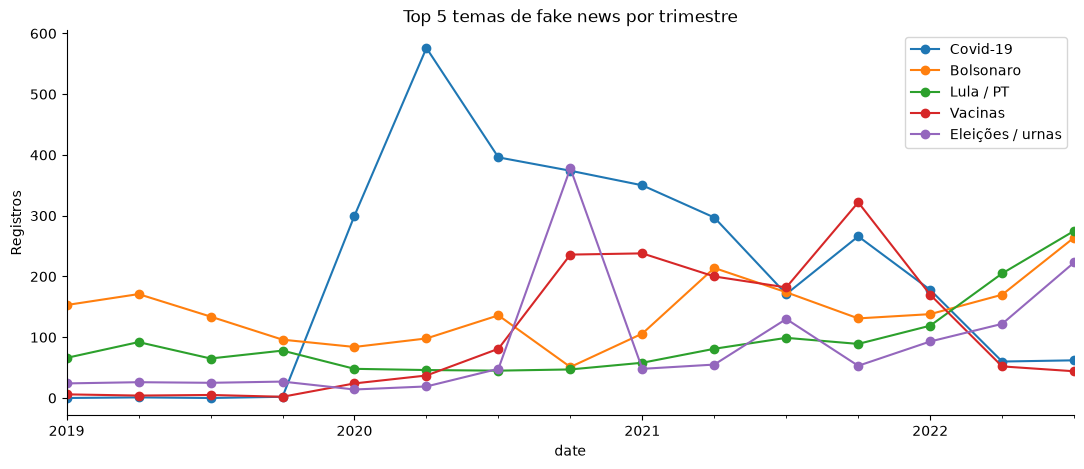

In [23]:
top5 = df.loc[df["classe"] == "Fake", list(TEMAS)].sum().nlargest(5).index
temas_tempo = (df.query("classe == 'Fake' and date >= '2019-01-01'")
                 .set_index("date")[top5]
                 .resample("QS").sum()
                 .iloc[:-1])  # o último trimestre está incompleto

fig, ax = plt.subplots(figsize=(13, 5))
temas_tempo.plot(ax=ax, marker="o")
ax.set_title("Top 5 temas de fake news por trimestre")
ax.set_ylabel("Registros")
plt.show()

**As fake news seguem o noticiário:**
- **Covid** explode no início de 2020 e cai a partir de 2022.
- **Vacinas** sobem quando a vacinação começa (fim de 2020 e 2021).
- **Lula e eleições** crescem ao longo de 2022, ano de eleição presidencial.

Ou seja, **o assunto da desinformação muda rápido**. Um modelo que só aprende os assuntos de uma época perde eficácia na seguinte.

---
## 7. Desafios e oportunidades para as próximas etapas

### Desafios

| Desafio | Por que importa | Como lidar |
|---|---|---|
| **Classes desbalanceadas** (7,5 : 1) | Um modelo que responde "fake" para tudo acerta 88% | Usar F1, precisão e recall por classe; pesos de classe ou reamostragem |
| **Viés de fonte e de país** | ~97% das verdadeiras vêm de Polígrafo (PT) e Lupa; o modelo pode aprender a detectar "português de Portugal" | Filtrar só PT-BR, ou garantir que as agências apareçam em treino e teste; testar o modelo por agência |
| **Vazamento pela coluna `origin`** | Nome de político = verdadeira; rede social = fake | Não usar `origin` como variável do modelo |
| **Os assuntos mudam com o tempo** | Os dados vão até 2022; o assunto do momento sempre muda | Separar treino e teste por data; retreinar periodicamente |
| **Textos curtos e heterogêneos** | Metade das alegações tem até 14 palavras, pouco contexto | Combinar `title` + `text`; usar modelos de linguagem pré-treinados |
| **Datas faltando** (~12% das fakes) | Limita a separação temporal | Usar só os registros com data nessa etapa |

### Oportunidades

- **Variáveis de estilo:** a porcentagem de maiúsculas e o número de exclamações diferenciam as classes e **não dependem do assunto**, o que as torna mais robustas a mudanças de tema.
- **Modelos de linguagem em português:** textos curtos se beneficiam de modelos pré-treinados, como o **BERTimbau**, que entendem contexto além das palavras isoladas.
- **Temas como apoio:** o dicionário de temas pode alimentar filtros, painéis ou análises por assunto na aplicação.
- **Descoberta automática de temas:** técnicas como NMF, LDA ou BERTopic podem encontrar assuntos que o dicionário manual não cobre (os ~40% sem tema).
- **Mais dados verdadeiros:** coletar alegações verdadeiras de agências brasileiras reduziria tanto o desbalanceamento quanto o viés de fonte, e é **a melhoria de maior impacto**.

### Conclusão

Os dados têm **boa qualidade de conteúdo**: textos sempre preenchidos e poucos duplicados. As inconsistências de metadados (agências, origens e datas) foram corrigidas. Os padrões encontrados fazem sentido: as fake news se concentram em **política e saúde**, acompanham os eventos da época e têm um **estilo mais alarmista**.

O maior cuidado para as próximas etapas é o **viés de composição do dataset**: poucas verdadeiras, vindas quase só de duas agências e com forte presença de Portugal. Se isso não for tratado, o modelo pode parecer ótimo nos testes e falhar em notícias reais.